<a href="https://colab.research.google.com/github/jwr231000/Projects/blob/main/Burgers'_1_layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
using Random, Statistics, LinearAlgebra
Random.seed!(42)
u0(x) = -sin(pi*x)
α = 1e-2
β1 = 0.9
β2 = 0.999
ε = 1e-8
m=64
λ_pde, λ_ic, λ_bc, λ_data = 1.0, 10.0, 10.0, 10.0
x_max, x_min = 1.0, -1.0
t_max, t_min = 1.0, 0.0

N_coll, N_ic, N_bc, N_data = (1000,100,100,100)
x_coll = x_min .+ (x_max-x_min) .* rand(N_coll)
t_coll = t_min .+ (t_max-t_min) .* rand(N_coll)
x_data = x_min .+ (x_max-x_min) .* rand(N_data)
t_data = t_min .+ (t_max-t_min) .* rand(N_data)
x_shock = 0.1 .* randn(30)
t_shock = 0.3 .+ 0.2 .* rand(30)
x_data = vcat(x_data, x_shock)
t_data = vcat(t_data, t_shock)
x_ic = x_min .+ (x_max-x_min) .* rand(N_ic)
t_ic = zeros(N_ic)
t_bc = t_min .+ (t_max-t_min) .* rand(N_bc)



w1 = randn(m, 2) .* sqrt(2/(m+2))
w1[:, 2] .*= 3.0
w2 = randn(m,m) .* sqrt(2/(1+m))
w3 = randn(1,m) .* sqrt(2/(1+m))
b1 = zeros(m,1)
b2 = zeros(m,1)
b3 = 0.0

m_w1, v_w1 = zeros(size(w1)), zeros(size(w1))
m_w2, v_w2 = zeros(size(w2)), zeros(size(w2))
m_w3, v_w3 = zeros(size(w3)), zeros(size(w3))
m_b1, v_b1 = zeros(size(b1)), zeros(size(b1))
m_b2, v_b2 = zeros(size(b2)), zeros(size(b2))
m_b3, v_b3 = 0.0, 0.0

(0.0, 0.0)

In [ ]:
function forward(x_coll,t_coll,w1,w2,w3,b1,b2,b3)
  inputs = [x_coll';t_coll']
  z1 = w1 * inputs .+ b1
  a1 = tanh.(z1)
  z2 = w2 * a1 .+ b2
  a2 = tanh.(z2)
  u = w3 * a2 .+ b3
  return u, a1, a2
end

forward (generic function with 1 method)

In [ ]:
function analytic_loss(x_data,t_data,w1,w2,w3,b1,b2,b3)
  u, _, _ = forward(x_data,t_data,w1,w2,w3,b1,b2,b3)
  u_data = u_true.(x_data,t_data)
  L_data = mean((u .- u_data).^2)
  return L_data
  end



analytic_loss (generic function with 1 method)

In [ ]:
function residual(x_coll,t_coll,w1,w2,w3,b1,b2,b3)
  u, a1, a2 = forward(x_coll,t_coll,w1,w2,w3,b1,b2,b3)

  w1_x = w1[:,1]
  w1_t = w1[:,2]

  a1_squared = 1 .- a1.^2
  a2_squared = 1 .- a2.^2

  u_x = w3 * (a2_squared .* (w2 * (a1_squared .* w1_x)))
  u_t = w3 * (a2_squared .* (w2 * (a1_squared .* w1_t)))

  r = u_t .+ u .* u_x
  return r, u_t, u_x, u, a1, a2
end

residual (generic function with 1 method)

In [ ]:
function loss(N_coll,N_ic,N_bc,x_coll,t_coll,w1,w2,w3,b1,b2,b3,x_ic,t_ic,t_bc,x_min,x_max)
  r, _, _, _, _, _ = residual(x_coll,t_coll,w1,w2,w3,b1,b2,b3)
  L_pde = mean(r.^2)

  u_ic, _ = forward(x_ic,t_ic,w1,w2,w3,b1,b2,b3)
  L_ic = mean((vec(u_ic) .- u0.(x_ic)).^2)

  x_left  = fill(x_min, N_bc)
  x_right = fill(x_max, N_bc)
  u_blc, _ = forward(x_left,t_bc,w1,w2,w3,b1,b2,b3)
  u_brc, _ = forward(x_right,t_bc,w1,w2,w3,b1,b2,b3)
  L_bc = mean(u_blc.^2 .+ u_brc.^2)

  L_data = analytic_loss(x_data,t_data,w1,w2,w3,b1,b2,b3)

  L_tot = λ_pde * L_pde + λ_ic * L_ic + λ_bc * L_bc + λ_data * L_data
  return L_tot, L_pde, L_ic, L_bc, L_data
  end

loss (generic function with 1 method)

In [ ]:
function grad_pde(N_coll,x_coll,t_coll,w1,w2,w3,b1,b2,b3)
    r, u_t, u_x, u, a1, a2 = residual(x_coll,t_coll,w1,w2,w3,b1,b2,b3)
    r, u, u_x, u_t = vec(r), vec(u), vec(u_x), vec(u_t)

    a1_squared = 1 .- a1.^2
    a2_squared = 1 .- a2.^2

    delta = 2/N_coll .* r
    w1_x = w1[:,1]
    w1_t = w1[:,2]

    dw3 = ((delta .* u_x)' * a2'
              .+ (delta .* u)' * (a2_squared .* (w2 * (a1_squared .* w1_x)))'
              .+ delta' * (a2_squared .* (w2 * (a1_squared .* w1_t)))')

    db3 = u_x' * delta

    dw2 = ((u_x' .* (w3' .* a2_squared)) * (a1 .* delta')'
              .+ (u' .* (w3' .* a2_squared)) * ((a1_squared .* w1_x) .* delta')'
              .+ (w3' .* a2_squared) * ((a1_squared .* w1_t) .* delta')'
              .+ -2 .* (w3' .* (a2 .* a2_squared .* (w2 * (a1_squared .* w1_t)))) * (a1 .* delta')'
              .+ -2 .* (u' .* (w3' .* (a2 .* a2_squared .* (w2 * (a1_squared .* w1_x))))) * (a1 .* delta')')

    db2 = (((delta .* u_x)' * (w3' .* a2_squared)')'
              .+ -2 .* sum((delta' .* w3' .* (a2 .* a2_squared .* (w2 * (a1_squared .* w1_t)))), dims=2)
              .+ -2 .* sum(((delta .* u)' .* (w3' .* (a2 .* a2_squared .* (w2 * (a1_squared .* w1_x))))), dims=2))

    db1 = (u_x' .* (a1_squared .* (w2' * (w3' .* a2_squared)))
              .+ -2 .* ((w2' * (w3' .* a2_squared)) .* a1_squared .* a1 .* w1_t)
              .+ -2 .* u' .* ((w2' * (w3' .* a2_squared)) .* a1_squared .* a1 .* w1_x)
              .+ -2 .* a1_squared .* (w2' * (w3' .* (a2 .* a2_squared .* (w2* (a1_squared .* w1_t)))))
              .+ -2 .* u' .* (a1_squared .* (w2' * (w3' .* (a2 .* a2_squared .* (w2* (a1_squared .* w1_x))))) ) ) * delta

    dw1_x = ((u_x' .* (a1_squared .* (w2' * (w3' .* a2_squared)))
              .+ -2 .* ((w2' * (w3' .* a2_squared)) .* a1_squared .* a1 .* w1_t)
              .+ -2 .* u' .* ((w2' * (w3' .* a2_squared)) .* a1_squared .* a1 .* w1_x)
              .+ -2 .* a1_squared .* (w2' * (w3' .* (a2 .* a2_squared .* (w2* (a1_squared .* w1_t)))))
              .+ -2 .* u' .* (a1_squared .* (w2' * (w3' .* (a2 .* a2_squared .* (w2* (a1_squared .* w1_x))))) ) ) * (delta .* x_coll)
              .+ (a1_squared .* (w2' * (w3' .* a2_squared))) * (delta .* u))

    dw1_t = ((u_x' .* (a1_squared .* (w2' * (w3' .* a2_squared)))
              .+ -2 .* ((w2' * (w3' .* a2_squared)) .* a1_squared .* a1 .* w1_t)
              .+ -2 .* u' .* ((w2' * (w3' .* a2_squared)) .* a1_squared .* a1 .* w1_x)
              .+ -2 .* a1_squared .* (w2' * (w3' .* (a2 .* a2_squared .* (w2* (a1_squared .* w1_t)))))
              .+ -2 .* u' .* (a1_squared .* (w2' * (w3' .* (a2 .* a2_squared .* (w2* (a1_squared .* w1_x))))) ) ) * (delta .* t_coll)
              .+ (a1_squared .* (w2' * (w3' .* a2_squared))) * delta)

    dw1 = hcat(dw1_x, dw1_t)
    return db3, db2, db1, dw3, dw2, dw1
end

grad_pde (generic function with 1 method)

In [ ]:
function grad_ic(N_ic,x_ic,t_ic,w1,w2,w3,b1,b2,b3)
  u_ic, a1, a2 = forward(x_ic,t_ic,w1,w2,w3,b1,b2,b3)
  u_ic = vec(u_ic)

  a1_squared = 1 .- a1.^2
  a2_squared = 1 .- a2.^2

  r_ic = u_ic .- u0.(x_ic)
  delta = 2/N_ic .* r_ic

  db3_ic = sum(delta)
  dw3_ic = delta' * a2'
  db2_ic = vec(sum((w3' .* a2_squared) .* delta', dims=2))
  dw2_ic = ((w3' .* a2_squared) .* delta') * a1'
  db1_ic = (a1_squared .* (w2' * (w3' .* a2_squared))) * delta
  dw1_ic_x = (a1_squared .* (w2' * (w3' .* a2_squared))) * (delta .* x_ic)
  dw1_ic_t = a1_squared .* (w2' * (w3' .* a2_squared)) * (delta .* t_ic)
  dw1_ic = hcat(dw1_ic_x,dw1_ic_t)

  return db3_ic, db2_ic, db1_ic, dw3_ic, dw2_ic, dw1_ic

end

grad_ic (generic function with 1 method)

In [ ]:
function grad_bc(N_bc,t_bc,w1,w2,w3,b1,b2,b3)
  x_left  = fill(x_min, N_bc)
  x_right = fill(x_max, N_bc)


  u_left, a1, a2 = forward(x_left,t_bc,w1,w2,w3,b1,b2,b3)
  u_left = vec(u_left)

  a1_squared = 1 .- a1.^2
  a2_squared = 1 .- a2.^2

  delta = 2/N_bc .* u_left

  db3_left = sum(delta)
  dw3_left = delta' * a2'
  db2_left = vec(sum((w3' .* a2_squared) .* delta', dims=2))
  dw2_left = ((w3' .* a2_squared) .* delta') * a1'
  db1_left = (a1_squared .* (w2' * (w3' .* a2_squared))) * delta
  dw1_ic_x = (a1_squared .* (w2' * (w3' .* a2_squared))) * (delta .* x_left)
  dw1_ic_t = a1_squared .* (w2' * (w3' .* a2_squared)) * (delta .* t_bc)
  dw1_left = hcat(dw1_ic_x,dw1_ic_t)

  u_right, a1, a2 = forward(x_right,t_bc,w1,w2,w3,b1,b2,b3)
  u_right = vec(u_right)

  a1_squared = 1 .- a1.^2
  a2_squared = 1 .- a2.^2

  delta = 2/N_bc .* u_right

  db3_right = sum(delta)
  dw3_right = delta' * a2'
  db2_right = vec(sum((w3' .* a2_squared) .* delta', dims=2))
  dw2_right = ((w3' .* a2_squared) .* delta') * a1'
  db1_right = (a1_squared .* (w2' * (w3' .* a2_squared))) * delta
  dw1_ic_x = (a1_squared .* (w2' * (w3' .* a2_squared))) * (delta .* x_right)
  dw1_ic_t = a1_squared .* (w2' * (w3' .* a2_squared)) * (delta .* t_bc)
  dw1_right = hcat(dw1_ic_x,dw1_ic_t)

  db3_bc = db3_left + db3_right
  db2_bc = db2_left + db2_right
  db1_bc = db1_left + db1_right
  dw3_bc = dw3_left + dw3_right
  dw2_bc = dw2_left + dw2_right
  dw1_bc = dw1_left + dw1_right

  return db3_bc, db2_bc, db1_bc, dw3_bc, dw2_bc, dw1_bc
end

grad_bc (generic function with 1 method)

In [ ]:
function grads(N_coll, N_ic, N_bc, x_coll, t_coll, x_ic, t_ic, t_bc, w1, w2, w3, b1, b2, b3)
    db3_ic, db2_ic, db1_ic, dw3_ic, dw2_ic, dw1_ic  = grad_ic(N_ic,x_ic,t_ic,w1,w2,w3,b1,b2,b3)
    db3_bc, db2_bc, db1_bc, dw3_bc, dw2_bc, dw1_bc  = grad_bc(N_bc,t_bc,w1,w2,w3,b1,b2,b3)
    db3_pde, db2_pde, db1_pde, dw3_pde, dw2_pde, dw1_pde = grad_pde(N_coll,x_coll,t_coll,w1,w2,w3,b1,b2,b3)

    dw1 = λ_ic * dw1_ic .+ λ_bc * dw1_bc .+ λ_pde * dw1_pde
    dw2 = λ_ic * dw2_ic .+ λ_bc * dw2_bc .+ λ_pde * dw2_pde
    dw3 = λ_ic * dw3_ic .+ λ_bc * dw3_bc .+ λ_pde * dw3_pde
    db1 = λ_ic * db1_ic .+ λ_bc * db1_bc .+ λ_pde * db1_pde
    db2 = λ_ic * db2_ic  + λ_bc * db2_bc  + λ_pde * db2_pde
    db3 = λ_ic * db3_ic  + λ_bc * db3_bc  + λ_pde * db3_pde

    return dw1, dw2, dw3, db1, db2, db3
end

grads (generic function with 1 method)

In [ ]:
function optim(w1,w2,w3,b1,b2,b3,dw1,dw2,dw3,db1,db2,db3,α,ε,m_w1,m_w2,m_w3,v_w1,v_w2,v_w3,m_b1,m_b2,m_b3,v_b1,v_b2,v_b3,β1,β2)
  m_w1, v_w1  = β1*m_w1 +(1-β1)*dw1, β2*v_w1 + (1-β2)*dw1.^2
  m_w2, v_w2  = β1*m_w2 +(1-β1)*dw2, β2*v_w2 + (1-β2)*dw2.^2
  m_w3, v_w3  = β1*m_w3 +(1-β1)*dw3, β2*v_w3 + (1-β2)*dw3.^2
  m_b1, v_b1  = β1*m_b1 +(1-β1)*db1, β2*v_b1 + (1-β2)*db1.^2
  m_b2, v_b2  = β1*m_b2 +(1-β1)*db2, β2*v_b2 + (1-β2)*db2.^2
  m_b3, v_b3  = β1*m_b3 +(1-β1)*db3, β2*v_b3 + (1-β2)*db3.^2
  w1 -= α .* m_w1 ./(sqrt.(v_w1) .+ ε)
  w2 -= α .* m_w2 ./(sqrt.(v_w2) .+ ε)
  w3 -= α .* m_w3 ./(sqrt.(v_w3) .+ ε)
  b1 -= α .* m_b1 ./(sqrt.(v_b1) .+ ε)
  b2 -= α .* m_b2 ./(sqrt.(v_b2) .+ ε)
  b3 -= α .* m_b3 ./(sqrt.(v_b3) .+ ε)
  return w1, w2, w3, b1, b2, b3, m_w1, m_w2, m_w3, v_w1, v_w2, v_w3, m_b1, m_b2, m_b3, v_b1, v_b2, v_b3
end

optim (generic function with 1 method)

In [ ]:
using OrdinaryDiffEq
function _burgers_reference(N=2000, T=1.0, ν=0.01/π)
    dx = 2.0 / (N + 1)
    x_int = -1.0 .+ dx .* (1:N)
    u0 = -sin.(π .* x_int)

    function rhs!(du, u, p, t)
        @inbounds for i in 1:N
            u_L = (i == 1) ? 0.0 : u[i-1]
            u_R = (i == N) ? 0.0 : u[i+1]
            u_i = u[i]
            conv = u_i >= 0 ? u_i*(u_i - u_L)/dx : u_i*(u_R - u_i)/dx
            diff = ν * (u_R - 2*u_i + u_L) / dx^2
            du[i] = -conv + diff
        end
    end

    prob = ODEProblem(rhs!, u0, (0.0, T))
    sol  = solve(prob, Tsit5(), saveat=0.01, abstol=1e-9, reltol=1e-9)
    return x_int, sol.t, hcat(sol.u...)
end

const _BURGERS_REF = Ref{Any}(nothing)


function u_true(x, t)
    if _BURGERS_REF[] === nothing
        _BURGERS_REF[] = _burgers_reference()
    end
    x_grid, t_grid, u_mat = _BURGERS_REF[]

    ix = clamp(searchsortedlast(x_grid, x), 1, length(x_grid) - 1)
    it = clamp(searchsortedlast(t_grid, t), 1, length(t_grid) - 1)

    fx = (x - x_grid[ix]) / (x_grid[ix+1] - x_grid[ix])
    ft = (t - t_grid[it]) / (t_grid[it+1] - t_grid[it])

    return (1-fx)*(1-ft) * u_mat[ix,   it  ] +
           fx     *(1-ft)* u_mat[ix+1, it  ] +
           (1-fx) *ft    * u_mat[ix,   it+1] +
           fx     *ft    * u_mat[ix+1, it+1]
end

u_true (generic function with 1 method)

In [ ]:
n_steps = 20000

loss_history = Float64[]
lpde_history = Float64[]
lic_history  = Float64[]
lbc_history  = Float64[]
ldata_history = Float64[]

for step in 1:n_steps
    L_tot, L_pde, L_ic, L_bc, L_data = loss(N_coll,N_ic,N_bc,x_coll,t_coll,w1,w2,w3,b1,b2,b3,x_ic,t_ic,t_bc,x_min,x_max)
    push!(loss_history, L_tot)
    push!(lpde_history, L_pde)
    push!(lic_history,  L_ic)
    push!(lbc_history,  L_bc)
    push!(ldata_history, L_data)

    dw1, dw2, dw3, db1, db2, db3 = grads(N_coll, N_ic, N_bc, x_coll, t_coll, x_ic, t_ic, t_bc, w1, w2, w3, b1, b2, b3)
    w1, w2, w3, b1, b2, b3, m_w1, m_w2, m_w3, v_w1, v_w2, v_w3, m_b1, m_b2, m_b3, v_b1, v_b2, v_b3 = optim(w1,w2,w3,b1,b2,b3,dw1,dw2,dw3,db1,db2,db3,α,ε,m_w1,m_w2,m_w3,v_w1,v_w2,v_w3,m_b1,m_b2,m_b3,v_b1,v_b2,v_b3,β1,β2)
    if step < n_steps/4
           λ_pde, λ_ic, λ_bc, λ_data = 0.01, 100.0, 10.0, 10.0
       elseif step < n_steps/2
           λ_pde, λ_ic, λ_bc, λ_data = 10.0, 10.0, 10.0, 10.0
       elseif step < 3 * n_steps /4
           λ_pde, λ_ic, λ_bc, λ_data = 10.0, 1.0, 1.0, 10.0
       else
           λ_pde, λ_ic, λ_bc, λ_data = 10.0, 1.0, 1.0, 10.0
    end

    if step % 500 == 0 || step == 1
        println("step $step  L_tot=$(round(L_tot, sigdigits=5))  ",
                "L_pde=$(round(L_pde, sigdigits=5))  ",
                "L_ic=$(round(L_ic, sigdigits=5))  ",
                "L_bc=$(round(L_bc, sigdigits=5)) ",
                "L_data=$(round(L_data, sigdigits=5))")
    end
end

step 1  L_tot=13.672  L_pde=0.1285  L_ic=0.63535  L_bc=0.1984 L_data=0.52059
step 500  L_tot=6.6709  L_pde=0.83937  L_ic=1.4888e-5  L_bc=0.0010321 L_data=0.66507
step 1000  L_tot=6.6509  L_pde=0.65311  L_ic=8.0982e-6  L_bc=0.00034909 L_data=0.66401
step 1500  L_tot=6.6252  L_pde=0.54855  L_ic=4.3318e-6  L_bc=7.0198e-5 L_data=0.66186
step 2000  L_tot=6.6297  L_pde=0.50765  L_ic=4.0839e-6  L_bc=2.2164e-5 L_data=0.6624
step 2500  L_tot=6.5821  L_pde=0.50307  L_ic=0.00047452  L_bc=0.0010432 L_data=0.65192
step 3000  L_tot=6.7716  L_pde=0.453  L_ic=3.3541e-6  L_bc=1.3908e-5 L_data=0.67666
step 3500  L_tot=6.5902  L_pde=0.45257  L_ic=1.1051e-5  L_bc=3.7047e-5 L_data=0.65842
step 4000  L_tot=6.7106  L_pde=0.43623  L_ic=4.6578e-6  L_bc=1.7993e-5 L_data=0.67056
step 4500  L_tot=6.6801  L_pde=0.43145  L_ic=4.9892e-6  L_bc=1.9678e-5 L_data=0.66751
step 5000  L_tot=6.6816  L_pde=0.42394  L_ic=4.5418e-6  L_bc=1.9749e-5 L_data=0.66767
step 5500  L_tot=7.1729  L_pde=0.032545  L_ic=0.04882  L_bc=0.000

In [ ]:
function burgers_analytic_curve(t; N = 400)
    if t < 1/π - 1e-6

        x_0 = range(-1.0, 1.0, length = N)
        u_0 = -sin.(π .* x_0)
        x_t = x_0 .+ u_0 .* t
        idx = sortperm(x_t)
        return x_t[idx], u_0[idx]
    else

        f(x_0) = x_0 - sin(π * x_0) * t
        lo, hi = 1e-8, 1.0 - 1e-8
        for _ in 1:80
            mid = 0.5 * (lo + hi)
            if f(mid) < 0
                lo = mid
            else
                hi = mid
            end
        end
        a = 0.5 * (lo + hi)

        x_0_L = range(-1.0, -a, length = N ÷ 2)
        u_L   = -sin.(π .* x_0_L)
        x_L   = x_0_L .+ u_L .* t
        idx_L = sortperm(x_L)

        x_0_R = range(a, 1.0, length = N ÷ 2)
        u_R   = -sin.(π .* x_0_R)
        x_R   = x_0_R .+ u_R .* t
        idx_R = sortperm(x_R)

        x_full = vcat(x_L[idx_L], x_R[idx_R])
        u_full = vcat(u_L[idx_L], u_R[idx_R])
        return x_full, u_full
    end
end

function plot_pinn_vs_analytic(w1, w2, w3, b1, b2, b3;
                               t_slices = [0.1, 0.2, 0.318, 0.4, 0.5, 0.9],
                               Nx = 500)
    xs = collect(range(x_min, x_max, length = Nx))
    panels = []

    for t in t_slices

        u_pred_mat, _, _ = forward(xs, fill(t, Nx), w1, w2, w3, b1, b2, b3)
        u_pred = vec(u_pred_mat)


        x_an, u_an = burgers_analytic_curve(t)

        p = plot(x_an, u_an;  lw = 2,   ls = :dash, color = :red,
                              label = "analytic")
        plot!(p, xs, u_pred;  lw = 2.5, color = :blue, label = "PINN")

        if t > 1/π
            vline!(p, [0.0]; color = :gray, ls = :dot, lw = 0.7, label = "")
        end

        title!(p, "t = $(round(t, digits = 3))")
        xlabel!(p, "x"); ylabel!(p, "u")
        ylims!(p, (-1.2, 1.2))
        xlims!(p, (x_min, x_max))
        push!(panels, p)
    end

    return plot(panels...; layout = (3, 2), size = (1100, 1000))
end

plot_pinn_vs_analytic (generic function with 1 method)

In [ ]:
using Plots

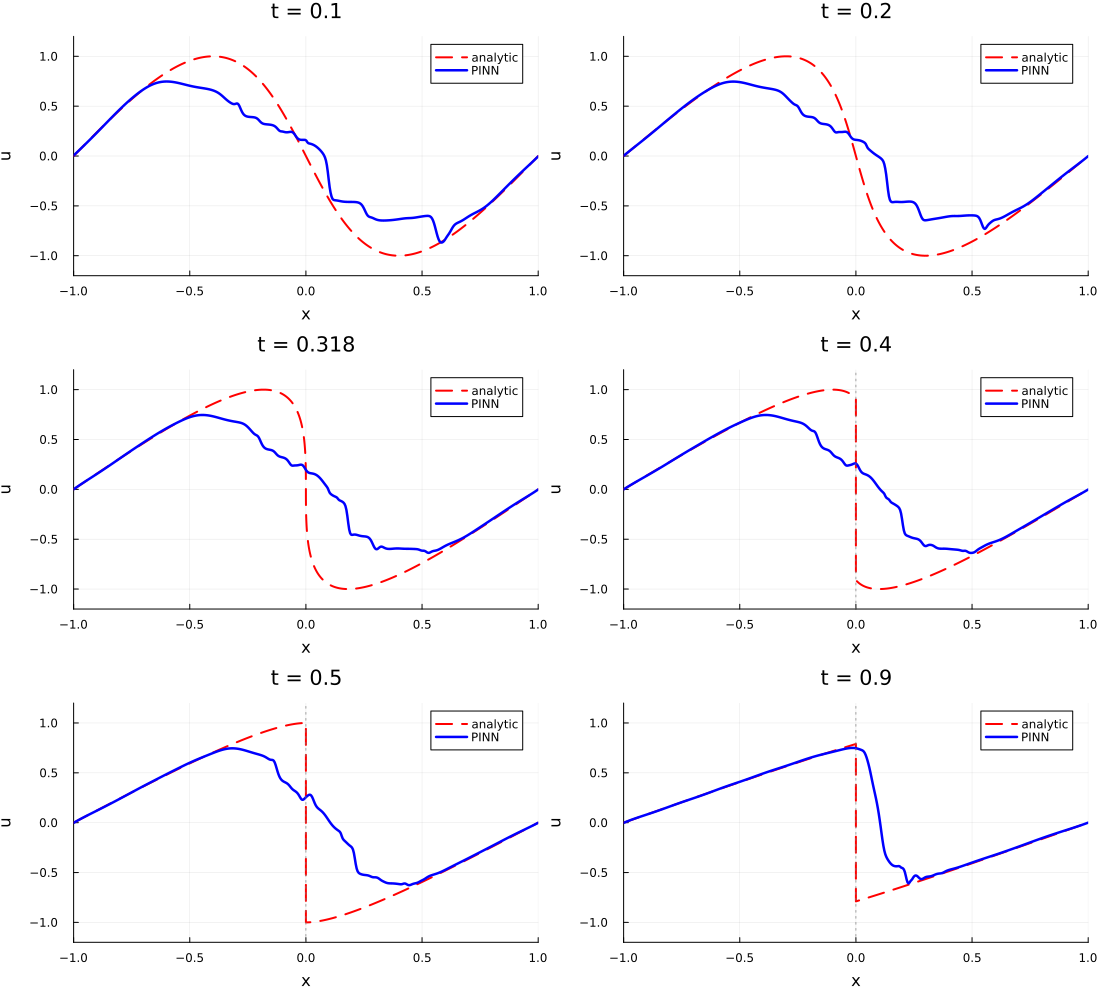

In [ ]:
display(plot_pinn_vs_analytic(w1, w2, w3, b1, b2, b3))

In [ ]:
using Pkg
Pkg.add("OrdinaryDiffEq")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
